In [1]:
print("hola");

hola


────────────────────────────────────────
  Beta (Cov/Var):        -0.9364
  Slope OLS (scatter):   -0.9364  (R²=0.728, p=0.0000)
  Pendiente reference:   +0.00789 / período
  Pendiente asset:       -0.00023 / período
  Diferencia pendientes: -0.00813
────────────────────────────────────────


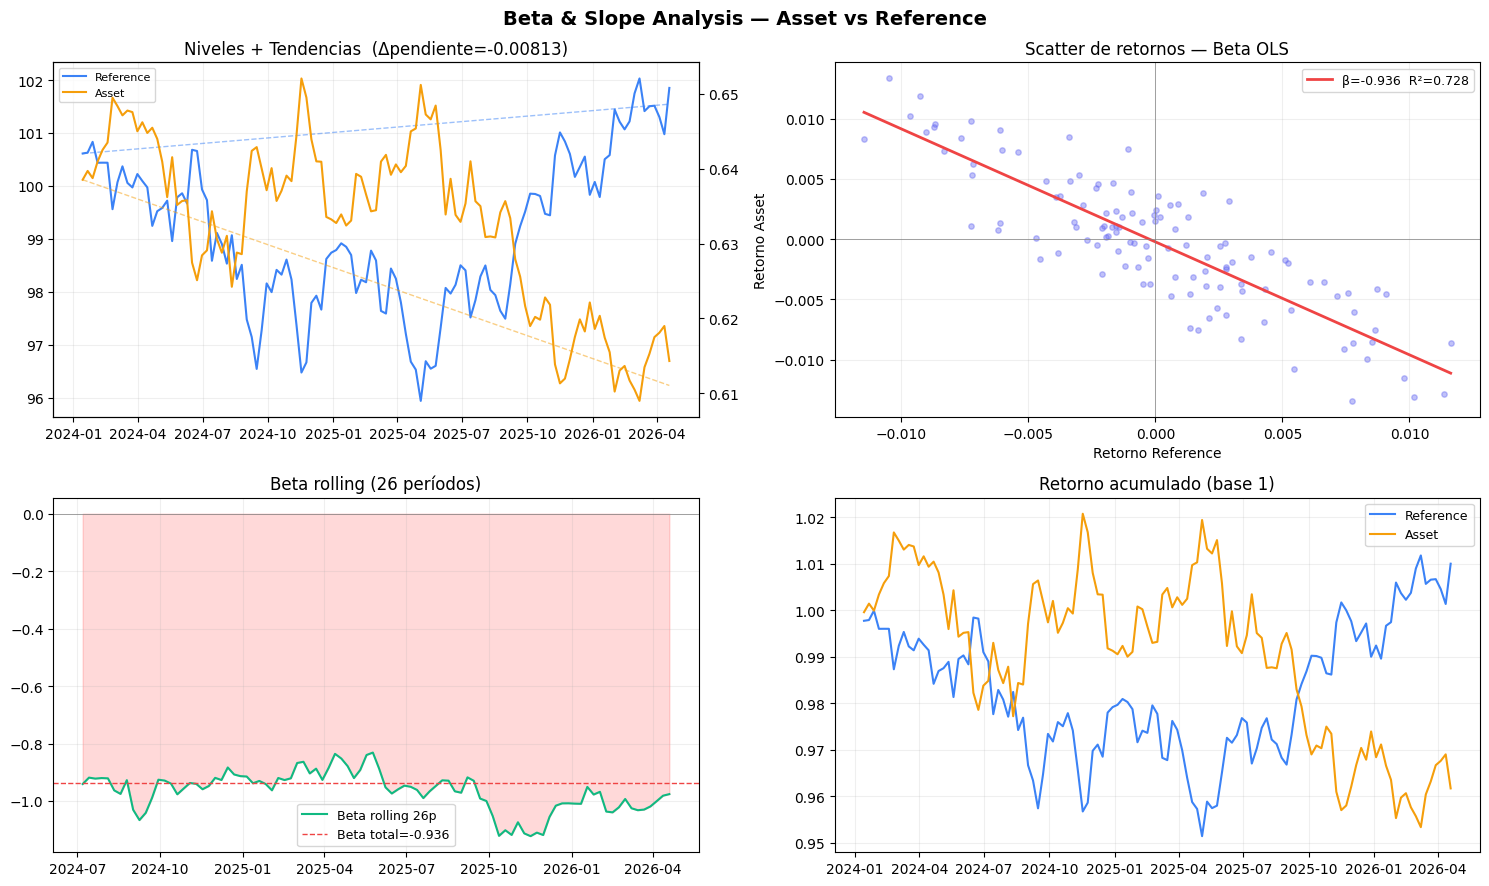

In [3]:
# Beta & Slope Analysis — Asset vs Reference Series
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# ── 1. DATOS SIMULADOS (reemplaza con tus series reales) ──────────────────────
np.random.seed(7)
n = 120  # 120 períodos (ej: días o semanas)

# Serie de referencia: índice DXY o macro factor
reference = np.cumsum(np.random.randn(n) * 0.5) + 100

# Activo: AUD/USD con correlación parcial al reference + ruido propio
beta_true = -0.6  # relación inversa típica AUD/USD vs DXY
asset = 0.65 + beta_true * 0.01 * (reference - reference.mean()) + \
        np.cumsum(np.random.randn(n) * 0.002)

dates = pd.date_range('2024-01-01', periods=n, freq='W')
df = pd.DataFrame({'reference': reference, 'asset': asset}, index=dates)

# ── 2. RETORNOS (para beta clásica necesitas cambios, no niveles) ─────────────
df['ret_ref'] = df['reference'].pct_change()
df['ret_asset'] = df['asset'].pct_change()
df = df.dropna()

# ── 3. REGRESIÓN LINEAL — BETA Y PENDIENTES ───────────────────────────────────
# Beta = Cov(asset, ref) / Var(ref)
beta = df['ret_asset'].cov(df['ret_ref']) / df['ret_ref'].var()

# OLS con scipy para obtener pendiente, intercept, R², p-value
slope, intercept, r_value, p_value, std_err = stats.linregress(
    df['ret_ref'], df['ret_asset']
)

# Pendiente de cada serie contra el tiempo (tendencia propia)
t = np.arange(len(df))
slope_ref,  *_ = stats.linregress(t, df['reference'].values)
slope_asset,*_ = stats.linregress(t, df['asset'].values)
slope_diff = slope_asset - slope_ref

print(f"{'─'*40}")
print(f"  Beta (Cov/Var):        {beta:+.4f}")
print(f"  Slope OLS (scatter):   {slope:+.4f}  (R²={r_value**2:.3f}, p={p_value:.4f})")
print(f"  Pendiente reference:   {slope_ref:+.5f} / período")
print(f"  Pendiente asset:       {slope_asset:+.5f} / período")
print(f"  Diferencia pendientes: {slope_diff:+.5f}")
print(f"{'─'*40}")

# ── 4. BETA ROLLING (cómo cambia la relación en el tiempo) ────────────────────
window = 26  # 26 semanas ≈ 6 meses
df['beta_rolling'] = (
    df['ret_asset'].rolling(window).cov(df['ret_ref']) /
    df['ret_ref'].rolling(window).var()
)

# ── 5. VISUALIZACIÓN ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
fig.suptitle('Beta & Slope Analysis — Asset vs Reference', fontsize=14, fontweight='bold')

# — Panel 1: Niveles con líneas de tendencia
ax = axes[0, 0]
ax2 = ax.twinx()
l1, = ax.plot(df.index, df['reference'], color='#3b82f6', label='Reference', lw=1.5)
l2, = ax2.plot(df.index, df['asset'], color='#f59e0b', label='Asset', lw=1.5)
# Trend lines
trend_ref   = slope_ref   * t + df['reference'].iloc[0]
trend_asset = slope_asset * t + df['asset'].iloc[0]
ax.plot(df.index,  trend_ref,   '--', color='#3b82f6', alpha=0.5, lw=1)
ax2.plot(df.index, trend_asset, '--', color='#f59e0b', alpha=0.5, lw=1)
ax.set_title(f'Niveles + Tendencias  (Δpendiente={slope_diff:+.5f})')
ax.legend(handles=[l1, l2], loc='upper left', fontsize=8)
ax.grid(alpha=0.2)

# — Panel 2: Scatter retornos + recta de regresión
ax = axes[0, 1]
ax.scatter(df['ret_ref'], df['ret_asset'], alpha=0.4, s=15, color='#6366f1')
x_line = np.linspace(df['ret_ref'].min(), df['ret_ref'].max(), 100)
ax.plot(x_line, slope * x_line + intercept, color='#ef4444', lw=2,
        label=f'β={beta:.3f}  R²={r_value**2:.3f}')
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
ax.set_xlabel('Retorno Reference'); ax.set_ylabel('Retorno Asset')
ax.set_title('Scatter de retornos — Beta OLS')
ax.legend(fontsize=9); ax.grid(alpha=0.2)

# — Panel 3: Beta rolling
ax = axes[1, 0]
ax.plot(df.index, df['beta_rolling'], color='#10b981', lw=1.5, label=f'Beta rolling {window}p')
ax.axhline(beta, color='#ef4444', linestyle='--', lw=1, label=f'Beta total={beta:.3f}')
ax.axhline(0, color='gray', lw=0.5)
ax.fill_between(df.index, df['beta_rolling'], 0,
                where=df['beta_rolling'] > 0, alpha=0.15, color='green')
ax.fill_between(df.index, df['beta_rolling'], 0,
                where=df['beta_rolling'] <= 0, alpha=0.15, color='red')
ax.set_title(f'Beta rolling ({window} períodos)')
ax.legend(fontsize=9); ax.grid(alpha=0.2)

# — Panel 4: Retornos acumulados normalizados
ax = axes[1, 1]
cum_ref   = (1 + df['ret_ref']).cumprod()
cum_asset = (1 + df['ret_asset']).cumprod()
ax.plot(df.index, cum_ref,   color='#3b82f6', lw=1.5, label='Reference')
ax.plot(df.index, cum_asset, color='#f59e0b', lw=1.5, label='Asset')
ax.set_title('Retorno acumulado (base 1)')
ax.legend(fontsize=9); ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig('beta_analysis.png', dpi=150, bbox_inches='tight')
plt.show()